# Program - plot XY series in SCM and George's LES

**Content:**

- Open and Read SCM netCDF files
- Open and Read LES netCDF files
- Plot XY time series

**Author**: Yi-Hsuan Chen (yihsuan@umich.edu)

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import xarray as xr
import io, os, sys, types

import yhc_module as yhc
#import read_data as read_data   ## on GFDL PP/AN
import read_data_big as read_data    ## on my Mac

#--- silence dask large chunk and silence the warning.
import dask
dask.config.set(**{'array.slicing.split_large_chunks': False})

xr.set_options(keep_attrs=True)  # keep attributes after xarray operation"

ERROR 1: PROJ: proj_create_from_database: Open of /lfs/opt/anaconda3/share/proj failed


# Read data

## Read RF01 LES intercomparison data

In [24]:
#--- Read RF01 LES intercomparison data
datapath_les_comp = "/lfs/home/yihsuanc/data/data.LES/DYCOMS2_RF01.LES_intercomparison/"
fname_les_comp = datapath_les_comp+"/"+"gcss7.nc"
ds_les_rf01_comp = xr.open_dataset(fname_les_comp)

les_rf01_lwp_mean = ds_les_rf01_comp.lwp_bar[0,:]  # units: g/m2
les_rf01_lwp_min = ds_les_rf01_comp.lwp_bar[2,:]
les_rf01_lwp_max = ds_les_rf01_comp.lwp_bar[3,:]
les_rf01_lwp_1qrtl = ds_les_rf01_comp.lwp_bar[4,:]
les_rf01_lwp_3qrtl = ds_les_rf01_comp.lwp_bar[5,:]

les_rf01_tt = ds_les_rf01_comp.time[:]/3600  # in hours

## Read RF02 LES intercomparison data

In [31]:
#--- Read RF02 LES intercomparison data
datapath_les_comp = "/lfs/home/yihsuanc/data/data.LES/DYCOMS2_RF02.LES_intercomparison/"
fname_les_comp = datapath_les_comp+"/"+"BLCWG_DYCOMS-II_RF02.scalars.nc"
ds_les_rf02_comp = xr.open_dataset(fname_les_comp)

dr=1
sed=1
varname1='lwp'
tt1=0
tt2=72

les_rf02_lwp_max = ds_les_rf02_comp.get(varname1)[:,dr, sed, tt1:tt2].max(dim='group')    # units: g/m2
les_rf02_lwp_min = ds_les_rf02_comp.get(varname1)[:,dr, sed, tt1:tt2].min(dim='group')
les_rf02_lwp_med = ds_les_rf02_comp.get(varname1)[:,dr, sed, tt1:tt2].median(dim='group'),
les_rf02_lwp_3qrtl = ds_les_rf02_comp.get(varname1)[:,dr, sed, tt1:tt2].quantile(0.75, dim='group')
les_rf02_lwp_1qrtl = ds_les_rf02_comp.get(varname1)[:,dr, sed, tt1:tt2].quantile(0.25, dim='group')
les_rf02_lwp_mean = ds_les_rf02_comp.get(varname1)[:,dr, sed, tt1:tt2].mean(dim='group')
les_rf02_tt = np.arange(0, tt2*300, 300) / 3600  # hours


#ds_les_rf02_comp
#les_rf02_tt

## Read SCM data

In [116]:
datapath = "/lfs/home/yihsuanc/test/x4-scm_dycoms/"

files_scm = {
    "rf01_tpdf":datapath+"q2_scm_taiesm1.dycomsrf01_yhc0509.dt_1200.macrop_tpdf/run/q2_scm_taiesm1.dycomsrf01_yhc0509.dt_1200.macrop_tpdf.cam.h0.1999-07-11-00000.nc",
    "rf02_tpdf":datapath+"q2_scm_taiesm1.dycomsrf02_yhc0509.dt_1200.macrop_tpdf/run/q2_scm_taiesm1.dycomsrf02_yhc0509.dt_1200.macrop_tpdf.cam.h0.1999-07-11-00000.nc",
    #"rf01_tpdf": datapath+"q2_scm_taiesm1.dycomsrf01.psflx.macrop_tpdf/run/q2_scm_taiesm1.dycomsrf01.psflx.macrop_tpdf.cam.h0.1999-07-11-00000.nc", 
    #"rf01_updf": datapath+"q2_scm_taiesm1.dycomsrf01.psflx.macrop_updf/run/q2_scm_taiesm1.dycomsrf01.psflx.macrop_updf.cam.h0.1999-07-11-00000.nc",
    #"rf02_tpdf": datapath+"q2_scm_taiesm1.dycomsrf02.psflx.macrop_tpdf/run/q2_scm_taiesm1.dycomsrf02.psflx.macrop_tpdf.cam.h0.1999-07-11-00000.nc",
    #"rf02_updf": datapath+"q2_scm_taiesm1.dycomsrf02.psflx.macrop_updf/run/q2_scm_taiesm1.dycomsrf02.psflx.macrop_updf.cam.h0.1999-07-11-00000.nc",
}

ds_scm_rf01 = xr.open_dataset(files_scm["rf01_tpdf"])
ds_scm_rf02 = xr.open_dataset(files_scm["rf02_tpdf"])

scm_rf01_lwp = yhc.unit_convert (ds_scm_rf01['TGCLDLWP'][:,0,0])
scm_rf01_tt = np.arange(0, len(ds_scm_rf01.time)) / 3  # hours

scm_rf02_lwp = yhc.unit_convert (ds_scm_rf02['TGCLDLWP'][:,0,0])
scm_rf02_tt = np.arange(0, len(ds_scm_rf02.time)) / 3  # hours
#scm_rf01_lwp

#len(scm_rf01_tt)

## Read LWP OBS

In [117]:
lwp_obs_rf01 = 75.4 # Stevens et al. (2007)
lwp_obs_rf02 = 137.4 # Stevens et al. (2007)

tt_obs_rf01 = [0.,4.]
tt_obs_rf02 = [0.,4.]

## Read hindcast 

# Plot

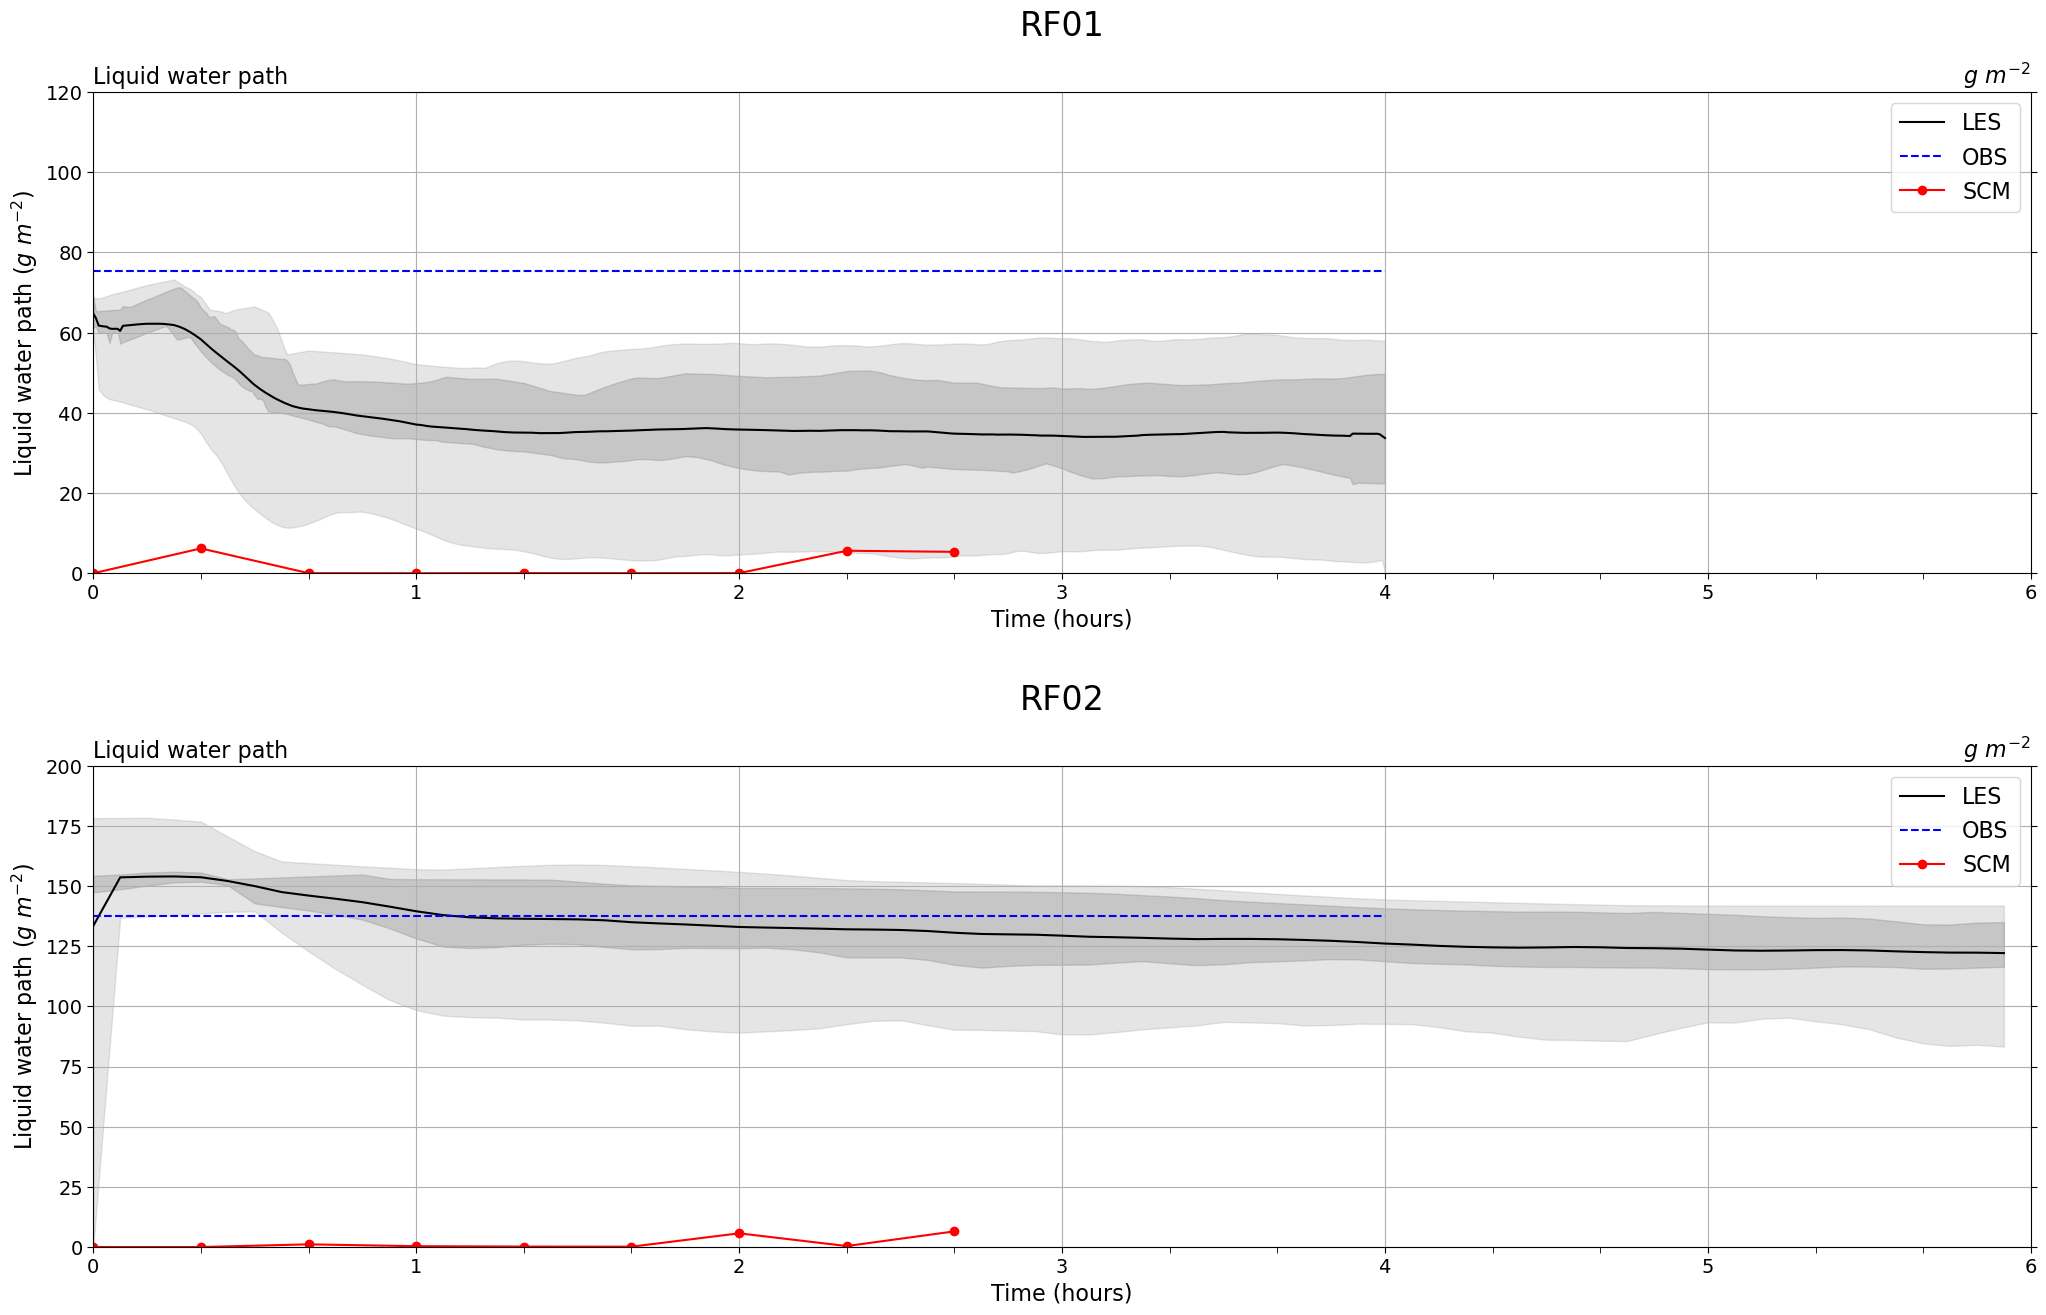

In [119]:
################
################
################
def plot_time_series_LWP_SCM_LES(ax, choice):

    if choice == "RF01":
        #--- LES intercomparison
        lwp_les_mean = les_rf01_lwp_mean
        lwp_les_min  = les_rf01_lwp_min
        lwp_les_max  = les_rf01_lwp_max
        lwp_les_1qrtl = les_rf01_lwp_1qrtl
        lwp_les_3qrtl = les_rf01_lwp_3qrtl
    
        tt_les = les_rf01_tt
    
        #--- SCM
        lwp_scm = scm_rf01_lwp
        tt_scm  = scm_rf01_tt
    
        #--- obs
        lwp_obs = lwp_obs_rf01
        tt_obs = tt_obs_rf01

        mainstring = "RF01"
        ylim = [0,120]
    
    elif choice == "RF02":
        #--- LES intercomparison
        lwp_les_mean = les_rf02_lwp_mean
        lwp_les_min  = les_rf02_lwp_min
        lwp_les_max  = les_rf02_lwp_max
        lwp_les_1qrtl = les_rf02_lwp_1qrtl
        lwp_les_3qrtl = les_rf02_lwp_3qrtl
    
        tt_les = les_rf02_tt
    
        #--- SCM
        lwp_scm = scm_rf02_lwp
        tt_scm  = scm_rf02_tt
    
        #--- obs
        lwp_obs = lwp_obs_rf02
        tt_obs = tt_obs_rf02
    
        mainstring = "RF02"
        ylim = [0,200]

    
    #--- plot les mean
    ax.plot (tt_les, lwp_les_mean, 'k-', label = "LES")
    
    #--- plot obs
    ax.plot (tt_obs, [lwp_obs,lwp_obs], 'b--', label="OBS")
    
    #--- plot SCM
    ax.plot (tt_scm, lwp_scm, 'r', marker="o", label = "SCM")
    
    #--- plot color fill of min/max
    ax.fill_between( 
        tt_les, lwp_les_min, lwp_les_max,color='gray', alpha=0.2,
            )
    
    #--- plot color fill of 1st/3rd qrtl 
    ax.fill_between( 
        tt_les, lwp_les_1qrtl, lwp_les_3qrtl ,color='gray', alpha=0.3,
            )
    
    ax.legend(fontsize = 16)
    ax.grid(True)
    ax.set_xlim(0,6)
    ax.set_ylim(ylim)

    fontsize_string = 16
    ax.set_title("Liquid water path", loc='left', fontsize = fontsize_string)
    ax.set_title(r"$g \ m^{-2}$", loc='right', fontsize = fontsize_string)
    ax.set_ylabel(r"Liquid water path ($g \ m^{-2}$)", fontsize = fontsize_string)
    ax.set_xlabel("Time (hours)", fontsize = fontsize_string)

    ax.tick_params(axis='both', which='both', direction='out', length=4, labelsize=14)  # This adds ticks to both axes
    #ax.tick_params(axis='x', which='both', top=True)  # Ticks on the top
    ax.tick_params(axis='y', which='both', right=True)  # Ticks on the right

    #set_minor_ticks(ax, 'x', n=2)
    ax.set_title(mainstring, loc='center', fontsize = 24, y=1.1)

    minor_ticks = np.arange(0, 6, 1/3)
    minor_ticks = minor_ticks[np.abs(minor_ticks % 1) > 1e-8]  # remove major tick overlaps
    ax.set_xticks(minor_ticks, minor=True)

#-----------
# do_test
#-----------
do_test = "111"

if do_test == "111":
    fig, (ax1,ax2) = plt.subplots(2,1, figsize=(25, 15))

    plot_time_series_LWP_SCM_LES(ax1, choice="RF01")
    plot_time_series_LWP_SCM_LES(ax2, choice="RF02")

    plt.subplots_adjust(hspace=0.4)  # Try values like 0.3, 0.5, etc.
